# 02 — Feature Engineering
**Dynamic Pricing Engine** | Mohit | github.com/dswithmohit/dynamic-pricing-engine

---
### Features built in this notebook
| Feature | Description |
|---|---|
| `competitor_price_ratio` | unit_price / competitor_price — competitive positioning |
| `demand_lag_7` | units_sold lagged 7 days — short-term momentum |
| `demand_lag_14` | units_sold lagged 14 days — medium-term trend |
| `rolling_demand_28` | 28-day rolling mean — smoothed demand signal |
| `seasonality_index` | sinusoidal month signal ∈ [0, 1] |
| `inventory_level` | simulated stock on hand — supply constraint |
| `price_to_avg_category` | item price / daily category average |
| `is_weekend`, `quarter` | calendar features |

In [9]:
import os
import sys

def _find_project_root(marker="src"):
    """Walk upward from the current working directory until a folder
    containing `marker` (the src/ package) is found. This works no matter
    where Jupyter was launched from, unlike a hardcoded os.path.abspath('..').
    """
    path = os.getcwd()
    while True:
        if os.path.isdir(os.path.join(path, marker)):
            return path
        parent = os.path.dirname(path)
        if parent == path:
            raise RuntimeError(
                f"Could not find project root (no '{marker}/' folder found "
                f"above {os.getcwd()}). Are you running Jupyter from inside "
                f"the project, or a totally different location?"
            )
        path = parent

PROJECT_ROOT = _find_project_root()
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False})

from src.data_loader import load_raw, build_synthetic_dataset
from src.features import build_features, feature_summary
from src.config import PROC_DIR, PROCESSED_CSV

## 1. Load Synthetic Dataset

In [10]:
try:
    df_raw = load_raw()
except FileNotFoundError:
    from src.data_loader import _make_seed_df
    df_raw = _make_seed_df()

df_synth = build_synthetic_dataset(df_raw, target_rows=500_000)
print(df_synth.shape)

[data_loader] Renamed columns: {'category': 'product_category', 'current_price': 'unit_price'}
[data_loader] Loaded raw data — 172,800 rows × 17 cols
[data_loader] Synthetic CSV already exists at /Users/mohit/Desktop/GitHub/dynamic-pricing-engine/data/processed/synthetic_500k.csv. Loading from disk.
(500000, 17)


## 2. Run Feature Pipeline

In [11]:
df_feat = build_features(df_synth)
feature_summary(df_feat)
df_feat.head(3)

[features] Feature matrix: 491,040 rows × 27 cols

FEATURE SUMMARY
Columns with nulls: 0

Final feature columns (27):
  base_price                          dtype=float64
  brand                               dtype=int8
  channel                             dtype=int8
  competitor_price                    dtype=float64
  competitor_price_ratio              dtype=float64
  date                                dtype=datetime64[ns]
  day_of_week                         dtype=int32
  demand_index                        dtype=float64
  demand_lag_14                       dtype=float64
  demand_lag_7                        dtype=float64
  discount_pct                        dtype=float64
  inventory_level                     dtype=float64
  is_weekend                          dtype=int64
  month                               dtype=int32
  price_change_pct                    dtype=float64
  price_to_avg_category               dtype=float64
  product_category                    dtype=int8
  prom

,date,product_category,brand,region,channel,season,base_price,unit_price,price_change_pct,discount_pct,...,month,day_of_week,is_weekend,quarter,competitor_price_ratio,price_to_avg_category,demand_lag_7,demand_lag_14,rolling_demand_28,seasonality_index
0,2021-01-11,6,21,2,0,1,183.147743,167.887246,0.0,5.029343,...,1,0,0,1,0.924387,0.887745,14.958875,12.132563,12.889349,0.067
1,2021-01-12,6,21,5,1,0,174.788683,123.740946,0.0,30.791017,...,1,1,0,1,1.103943,0.602709,9.920377,14.969023,12.641012,0.067
2,2021-01-13,6,21,5,2,0,182.969204,132.816528,0.0,14.860010,...,1,2,0,1,0.939695,0.816160,7.368372,12.530690,12.657830,0.067


## 3. Competitor Price Ratio Distribution

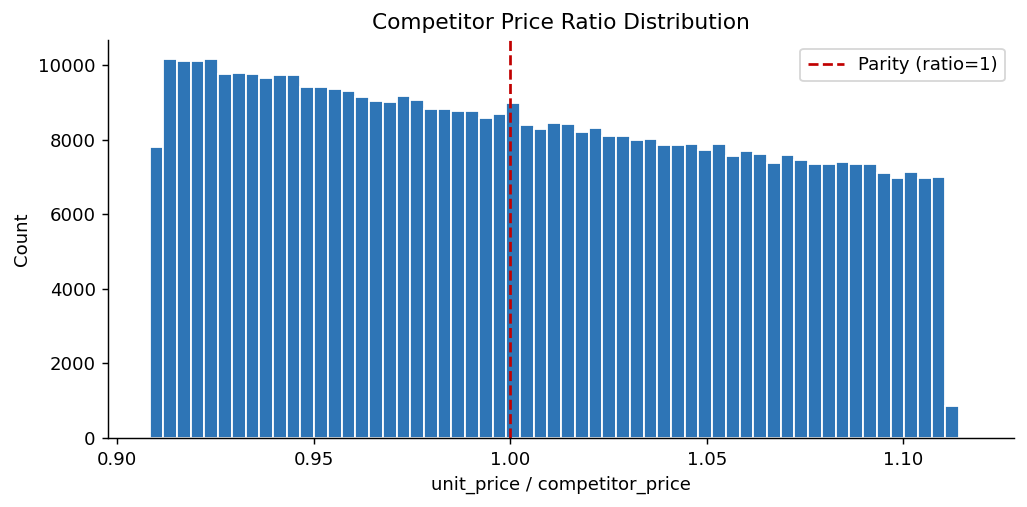

count    491040.000
mean          1.003
std           0.058
min           0.908
25%           0.953
50%           1.000
75%           1.053
max           1.118
Name: competitor_price_ratio, dtype: float64


In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df_feat['competitor_price_ratio'].clip(0.5, 1.5), bins=60,
        color='#2E75B6', edgecolor='white')
ax.axvline(1.0, color='#C00000', linestyle='--', linewidth=1.5, label='Parity (ratio=1)')
ax.set_title('Competitor Price Ratio Distribution')
ax.set_xlabel('unit_price / competitor_price')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/competitor_price_ratio.png', bbox_inches='tight')
plt.show()
print(df_feat['competitor_price_ratio'].describe().round(3))

## 4. Seasonality Index

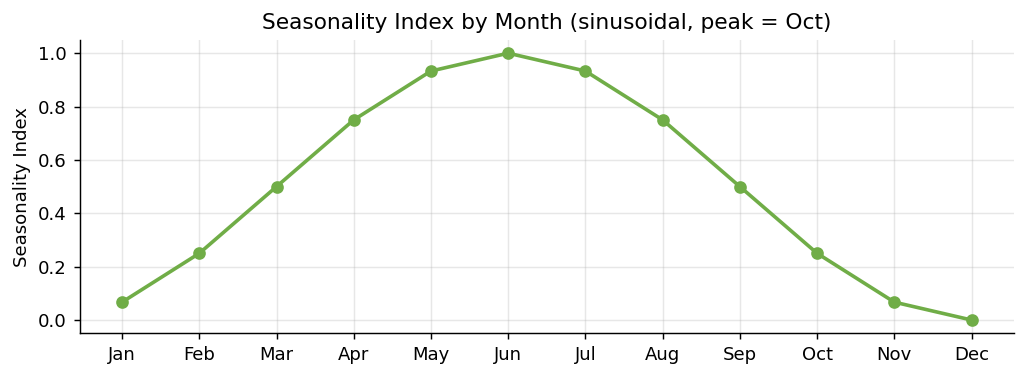

In [13]:
months = range(1, 13)
import numpy as np
si = [round(0.5 * (1 + np.sin(2 * np.pi * (m - 3) / 12)), 4) for m in months]

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(list(months), si, marker='o', color='#70AD47', linewidth=2)
ax.set_xticks(list(months))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax.set_title('Seasonality Index by Month (sinusoidal, peak = Oct)')
ax.set_ylabel('Seasonality Index')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/seasonality_index.png', bbox_inches='tight')
plt.show()

## 5. Demand Lag Correlation

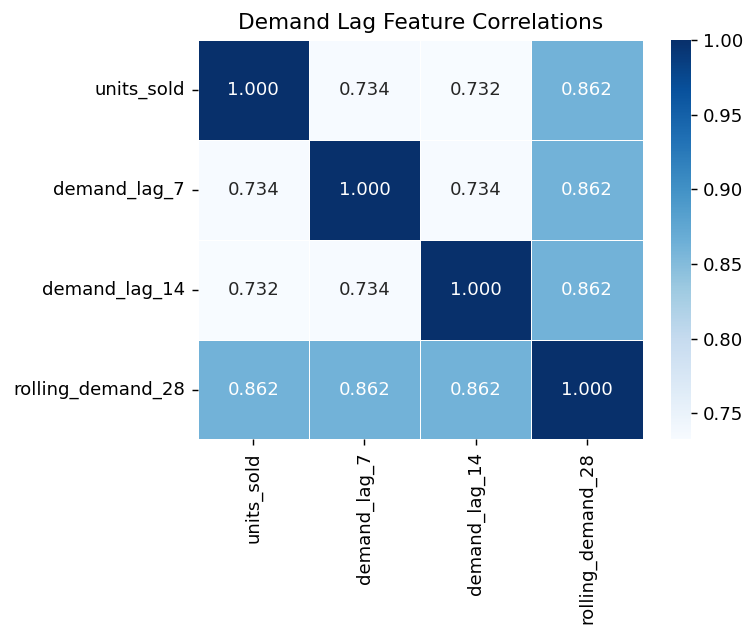

In [14]:
lag_cols = ['units_sold', 'demand_lag_7', 'demand_lag_14', 'rolling_demand_28']
lag_cols_present = [c for c in lag_cols if c in df_feat.columns]
corr = df_feat[lag_cols_present].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='Blues', ax=ax, linewidths=0.5)
ax.set_title('Demand Lag Feature Correlations')
plt.tight_layout()
plt.show()

## 6. Inventory Level Distribution

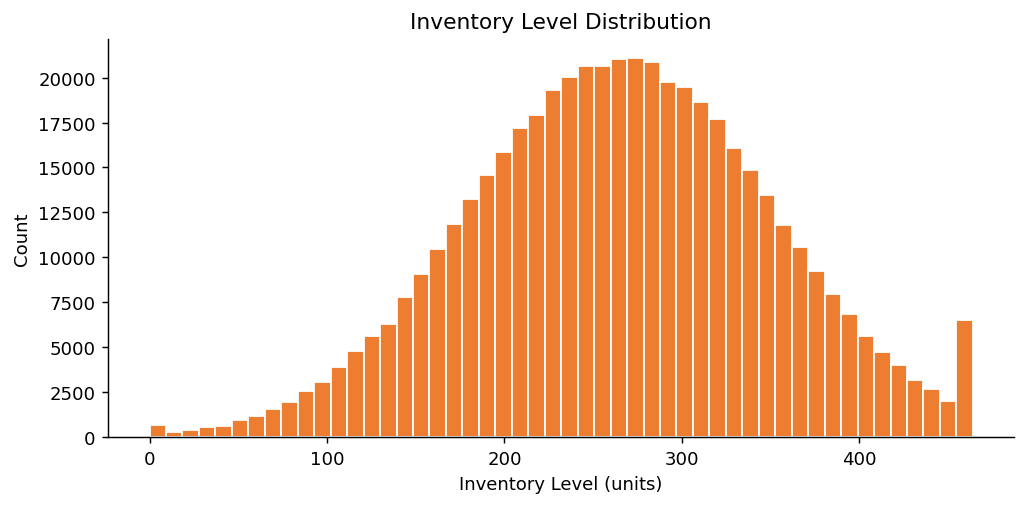

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df_feat['inventory_level'].clip(upper=df_feat['inventory_level'].quantile(0.99)),
        bins=50, color='#ED7D31', edgecolor='white')
ax.set_title('Inventory Level Distribution')
ax.set_xlabel('Inventory Level (units)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

## 7. Save Feature Matrix

In [16]:
df_feat.to_csv(PROCESSED_CSV, index=False)
print(f'Feature matrix saved → {PROCESSED_CSV}')
print(f'Shape: {df_feat.shape}')

Feature matrix saved → /Users/mohit/Desktop/GitHub/dynamic-pricing-engine/data/processed/features.csv
Shape: (491040, 27)


## Key Takeaways
- `competitor_price_ratio` is **centred near 1.0** — most products are priced competitively
- `demand_lag_7` and `demand_lag_14` have high autocorrelation — strong temporal persistence
- `seasonality_index` captures Oct–Dec peak demand period
- `inventory_level` adds supply-side signal — low stock correlates with higher prices

➡ Proceed to `03_elasticity_modeling.ipynb`